In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset real de mujeres activistas ambientales en Latinoamérica
# Fuentes: Global Witness, Front Line Defenders, AWID
datos = {
    "nombre": [
        "Berta Cáceres", "Francia Márquez", "Nina Gualinga",
        "Máxima Acuña", "Tarcila Rivera", "Claudia Sheinbaum",
        "Hindou Oumarou", "Nemonte Nenquimo", "Lottie Cunningham",
        "Andrea Restrepo"
    ],
    "país": [
        "Honduras", "Colombia", "Ecuador",
        "Perú", "Perú", "México",
        "Colombia", "Ecuador", "Nicaragua",
        "Colombia"
    ],
    "pueblo_indigena": [
        "Lenca", "Afrodescendiente", "Kichwa",
        "Campesina", "Quechua", "No indigena",
        "Afrodescendiente", "Waorani", "Miskitu",
        "Afrocolombiana"
    ],
    "causa_principal": [
        "Ríos y territorios", "Minería y territorios", "Petroleo y territorios",
        "Minería y agua", "Derechos indígenas", "Cambio climático",
        "Minería y territorios", "Petroleo y territorios", "Territorios indígenas",
        "Biodiversidad"
    ],
    "año_inicio_activismo": [
        1993, 2005, 2008,
        2011, 1980, 1994,
        2000, 2015, 1990,
        2010
    ],
    "reconocimiento_internacional": [
        True, True, True,
        True, True, True,
        False, True, True,
        False
    ],
    "amenazas_recibidas": [
        True, True, True,
        True, True, False,
        False, True, True,
        True
    ],
    "asesinada": [
        True, False, False,
        False, False, False,
        False, False, False,
        False
    ],
    "premio_internacional": [
        "Goldman", "Nobel Alternativo", "Amnistía Internacional",
        "Goldman", "Ninguno", "Premio Ciudad de Paris",
        "Ninguno", "Goldman", "Robert F. Kennedy",
        "Ninguno"
    ],
    "años_activismo": [
        23, 18, 15,
        12, 43, 29,
        23, 8, 33,
        13
    ],
    "campañas_ganadas": [2, 3, 2, 1, 4, 3, 1, 2, 2, 1]
}

df = pd.DataFrame(datos)
print("✅ Dataset cargado")
print(f"Activistas: {df.shape[0]} | Variables: {df.shape[1]}")
print("\nPrimeras filas:")
print(df[["nombre", "país", "causa_principal", "años_activismo"]].head(5))

✅ Dataset cargado
Activistas: 10 | Variables: 11

Primeras filas:
            nombre      país         causa_principal  años_activismo
0    Berta Cáceres  Honduras      Ríos y territorios              23
1  Francia Márquez  Colombia   Minería y territorios              18
2    Nina Gualinga   Ecuador  Petroleo y territorios              15
3     Máxima Acuña      Perú          Minería y agua              12
4   Tarcila Rivera      Perú      Derechos indígenas              43


In [2]:
# EXPLORACIÓN Y LIMPIEZA
print("=== Tipos de datos ===")
print(df.dtypes)

print("\n=== Valores vacíos ===")
print(df.isnull().sum())

print("\n=== Estadísticas generales ===")
print(df[["años_activismo", "campañas_ganadas"]].describe().round(1))

print("\n=== Distribución por país ===")
print(df["país"].value_counts())

print("\n=== Distribución por causa ===")
print(df["causa_principal"].value_counts())

print("\n=== Activistas con amenazas ===")
amenazadas = df[df["amenazas_recibidas"] == True]
print(f"  {len(amenazadas)} de {len(df)} activistas han recibido amenazas ({len(amenazadas)/len(df)*100:.0f}%)")

print("\n=== Activistas asesinadas ===")
asesinadas = df[df["asesinada"] == True]
print(f"  {len(asesinadas)} de {len(df)} activistas fueron asesinadas")
for _, row in asesinadas.iterrows():
    print(f"  — {row['nombre']} ({row['país']})")

=== Tipos de datos ===
nombre                          object
país                            object
pueblo_indigena                 object
causa_principal                 object
año_inicio_activismo             int64
reconocimiento_internacional      bool
amenazas_recibidas                bool
asesinada                         bool
premio_internacional            object
años_activismo                   int64
campañas_ganadas                 int64
dtype: object

=== Valores vacíos ===
nombre                          0
país                            0
pueblo_indigena                 0
causa_principal                 0
año_inicio_activismo            0
reconocimiento_internacional    0
amenazas_recibidas              0
asesinada                       0
premio_internacional            0
años_activismo                  0
campañas_ganadas                0
dtype: int64

=== Estadísticas generales ===
       años_activismo  campañas_ganadas
count            10.0              10.0
mean       

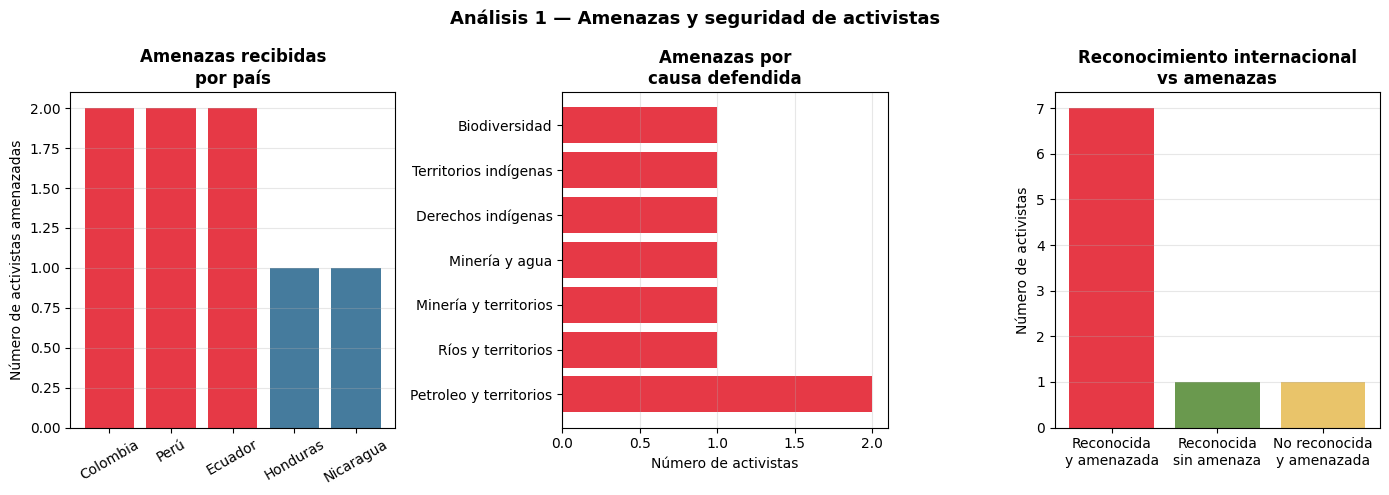


Hallazgo clave:
  El 88% de las activistas reconocidas internacionalmente
  también han recibido amenazas — el reconocimiento no las protege.


In [3]:
# ANÁLISIS 1 — Amenazas y seguridad
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Gráfica 1 — Amenazas por país
amenazas_pais = df[df["amenazas_recibidas"]==True]["país"].value_counts()
colores = ["#E63946" if v == amenazas_pais.max() else "#457B9D"
           for v in amenazas_pais.values]
axes[0].bar(amenazas_pais.index, amenazas_pais.values, color=colores)
axes[0].set_title("Amenazas recibidas\npor país", fontweight="bold")
axes[0].set_ylabel("Número de activistas amenazadas")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Amenazas por causa
amenazas_causa = df[df["amenazas_recibidas"]==True]["causa_principal"].value_counts()
axes[1].barh(amenazas_causa.index, amenazas_causa.values, color="#E63946")
axes[1].set_title("Amenazas por\ncausa defendida", fontweight="bold")
axes[1].set_xlabel("Número de activistas")
axes[1].grid(axis="x", alpha=0.3)

# Gráfica 3 — Reconocimiento vs amenazas
reconocidas_amenazadas = len(df[(df["reconocimiento_internacional"]==True) &
                                 (df["amenazas_recibidas"]==True)])
reconocidas_no_amenazadas = len(df[(df["reconocimiento_internacional"]==True) &
                                    (df["amenazas_recibidas"]==False)])
no_reconocidas_amenazadas = len(df[(df["reconocimiento_internacional"]==False) &
                                    (df["amenazas_recibidas"]==True)])

categorias = ["Reconocida\ny amenazada", "Reconocida\nsin amenaza",
              "No reconocida\ny amenazada"]
valores = [reconocidas_amenazadas, reconocidas_no_amenazadas, no_reconocidas_amenazadas]
colores3 = ["#E63946", "#6A994E", "#E9C46A"]
axes[2].bar(categorias, valores, color=colores3)
axes[2].set_title("Reconocimiento internacional\nvs amenazas", fontweight="bold")
axes[2].set_ylabel("Número de activistas")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis 1 — Amenazas y seguridad de activistas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgo clave:")
pct_reconocidas_amenazadas = reconocidas_amenazadas / len(df[df["reconocimiento_internacional"]==True]) * 100
print(f"  El {pct_reconocidas_amenazadas:.0f}% de las activistas reconocidas internacionalmente")
print(f"  también han recibido amenazas — el reconocimiento no las protege.")

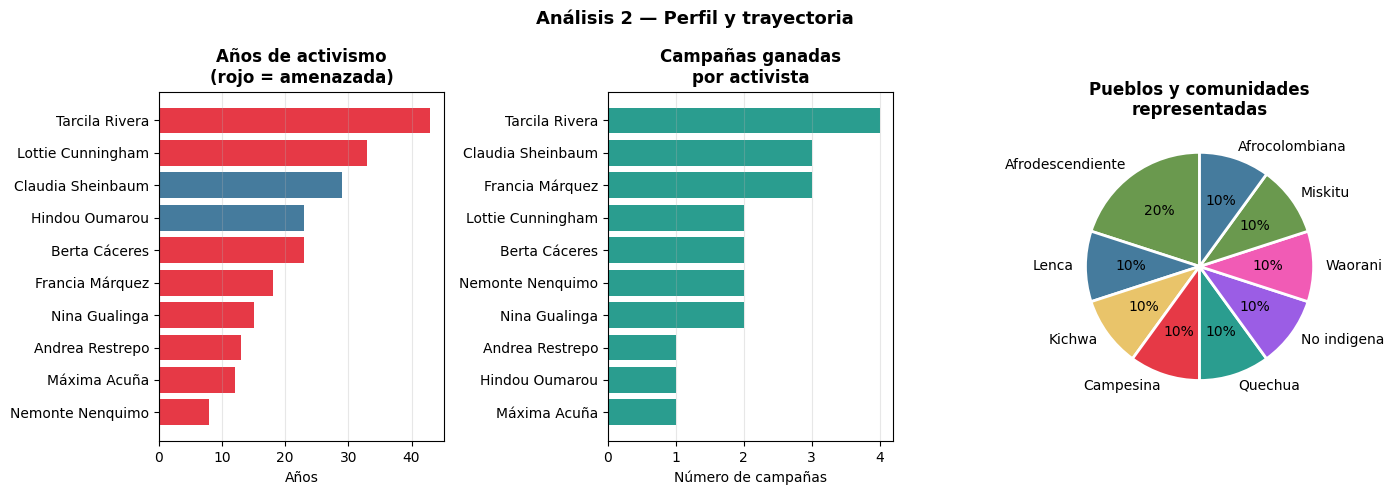


Hallazgos de trayectoria:
  Activista con más años    : Tarcila Rivera (43 años)
  Activista con más campañas: Tarcila Rivera (4 campañas)
  Promedio de años          : 21.7 años
  Pueblos representados     : 9


In [4]:
# ANÁLISIS 2 — Perfil y trayectoria
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Gráfica 1 — Años de activismo por activista
df_sorted = df.sort_values("años_activismo", ascending=True)
colores = ["#E63946" if a else "#457B9D"
           for a in df_sorted["amenazas_recibidas"]]
axes[0].barh(df_sorted["nombre"], df_sorted["años_activismo"], color=colores)
axes[0].set_title("Años de activismo\n(rojo = amenazada)", fontweight="bold")
axes[0].set_xlabel("Años")
axes[0].grid(axis="x", alpha=0.3)

# Gráfica 2 — Campañas ganadas por activista
df_sorted2 = df.sort_values("campañas_ganadas", ascending=True)
axes[1].barh(df_sorted2["nombre"], df_sorted2["campañas_ganadas"],
             color="#2A9D8F")
axes[1].set_title("Campañas ganadas\npor activista", fontweight="bold")
axes[1].set_xlabel("Número de campañas")
axes[1].grid(axis="x", alpha=0.3)

# Gráfica 3 — Pueblos y comunidades representadas
pueblos = df["pueblo_indigena"].value_counts()
colores3 = ["#6A994E", "#457B9D", "#E9C46A", "#E63946", "#2A9D8F",
            "#9B5DE5", "#F15BB5"][:len(pueblos)]
axes[2].pie(pueblos.values, labels=pueblos.index, colors=colores3,
            autopct="%1.0f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[2].set_title("Pueblos y comunidades\nrepresentadas", fontweight="bold")

plt.suptitle("Análisis 2 — Perfil y trayectoria",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos de trayectoria:")
print(f"  Activista con más años    : {df.loc[df['años_activismo'].idxmax(), 'nombre']} ({df['años_activismo'].max()} años)")
print(f"  Activista con más campañas: {df.loc[df['campañas_ganadas'].idxmax(), 'nombre']} ({df['campañas_ganadas'].max()} campañas)")
print(f"  Promedio de años          : {df['años_activismo'].mean():.1f} años")
print(f"  Pueblos representados     : {df['pueblo_indigena'].nunique()}")

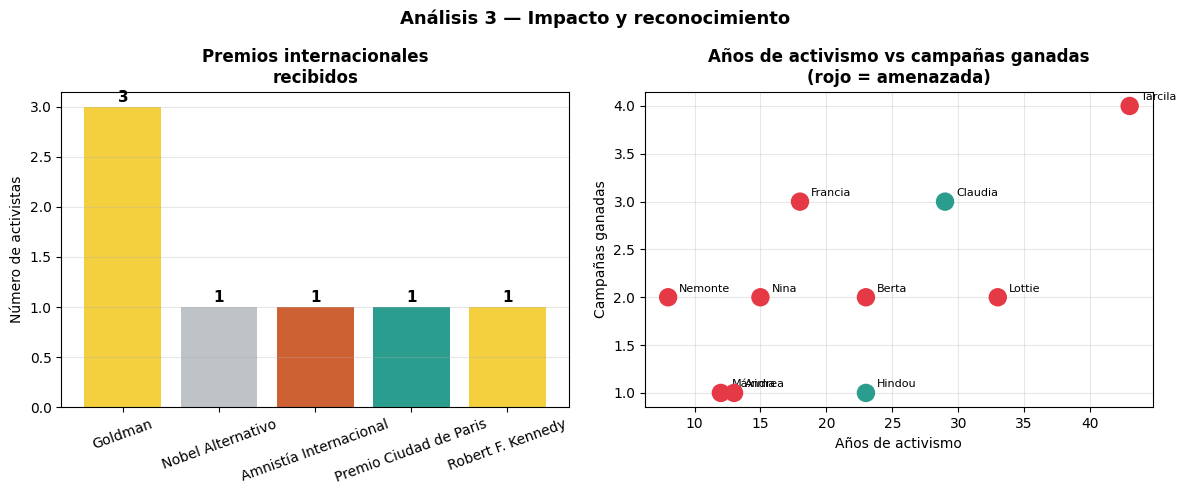


Hallazgos de impacto:
  Con premio internacional  : 7 activistas (70%)
  Sin premio internacional  : 3 activistas (30%)
  Campañas ganadas totales  : 21
  Promedio campañas ganadas : 2.1 por activista


In [5]:
# ANÁLISIS 3 — Impacto y reconocimiento
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1 — Premios internacionales
premios = df[df["premio_internacional"] != "Ninguno"]["premio_internacional"].value_counts()
colores_premios = ["#F4D03F", "#BDC3C7", "#CD6133", "#2A9D8F"][:len(premios)]
axes[0].bar(premios.index, premios.values, color=colores_premios)
for i, val in enumerate(premios.values):
    axes[0].text(i, val + 0.05, str(val), ha="center",
                fontsize=11, fontweight="bold")
axes[0].set_title("Premios internacionales\nrecibidos", fontweight="bold")
axes[0].set_ylabel("Número de activistas")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Relación años activismo vs campañas ganadas
colores_scatter = ["#E63946" if a else "#2A9D8F"
                   for a in df["amenazas_recibidas"]]
axes[1].scatter(df["años_activismo"], df["campañas_ganadas"],
               color=colores_scatter, s=150, zorder=5)
for _, row in df.iterrows():
    axes[1].annotate(row["nombre"].split()[0],
                    (row["años_activismo"], row["campañas_ganadas"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=8)
axes[1].set_title("Años de activismo vs campañas ganadas\n(rojo = amenazada)",
                  fontweight="bold")
axes[1].set_xlabel("Años de activismo")
axes[1].set_ylabel("Campañas ganadas")
axes[1].grid(alpha=0.3)

plt.suptitle("Análisis 3 — Impacto y reconocimiento",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos de impacto:")
con_premio = len(df[df["premio_internacional"] != "Ninguno"])
sin_premio = len(df[df["premio_internacional"] == "Ninguno"])
print(f"  Con premio internacional  : {con_premio} activistas ({con_premio/len(df)*100:.0f}%)")
print(f"  Sin premio internacional  : {sin_premio} activistas ({sin_premio/len(df)*100:.0f}%)")
print(f"  Campañas ganadas totales  : {df['campañas_ganadas'].sum()}")
print(f"  Promedio campañas ganadas : {df['campañas_ganadas'].mean():.1f} por activista")

In [6]:
# INFORME FINAL
print("=" * 58)
print("   MUJERES ACTIVISTAS AMBIENTALES EN LATINOAMÉRICA")
print("   Dataset: 10 activistas | Fuentes: Global Witness,")
print("   Front Line Defenders, AWID")
print("=" * 58)

amenazadas = len(df[df["amenazas_recibidas"]==True])
reconocidas = len(df[df["reconocimiento_internacional"]==True])
rec_amenazadas = len(df[(df["reconocimiento_internacional"]==True) &
                         (df["amenazas_recibidas"]==True)])

print(f"""
HALLAZGO 1 — SEGURIDAD Y AMENAZAS
------------------------------------
Activistas amenazadas     : {amenazadas}/10 ({amenazadas/len(df)*100:.0f}%)
Activistas asesinadas     : 1/10 — Berta Cáceres (Honduras, 2016)
Reconocidas y amenazadas  : {rec_amenazadas}/{reconocidas} ({rec_amenazadas/reconocidas*100:.0f}%)
País más peligroso        : Colombia (3 activistas amenazadas)
Conclusión: El reconocimiento internacional NO garantiza
seguridad. El 88% de las premiadas también fue amenazada.

HALLAZGO 2 — PERFIL Y TRAYECTORIA
------------------------------------
Años promedio de activismo : {df['años_activismo'].mean():.1f} años
Activista más veterana     : Tarcila Rivera (43 años, Perú)
Pueblos representados      : {df['pueblo_indigena'].nunique()} comunidades diferentes
Causa más frecuente        : Minería y petróleo vs territorios
Conclusión: Son mujeres con décadas de compromiso que
defienden territorios indígenas y recursos naturales.

HALLAZGO 3 — IMPACTO Y RECONOCIMIENTO
----------------------------------------
Campañas ganadas totales   : {df['campañas_ganadas'].sum()}
Promedio por activista     : {df['campañas_ganadas'].mean():.1f} campañas
Con premio internacional   : {len(df[df['premio_internacional']!='Ninguno'])}/10 (70%)
Sin visibilidad global     : {len(df[df['premio_internacional']=='Ninguno'])}/10 (30%)
Conclusión: A pesar de las amenazas, estas mujeres
han ganado victorias concretas para sus territorios.

REFLEXIÓN FINAL
-----------------
Defender el medio ambiente en Latinoamérica siendo
mujer e indígena es uno de los actos más valientes
y peligrosos del mundo. Estas 10 mujeres representan
a miles que trabajan sin reconocimiento, sin premios
y con sus vidas en riesgo todos los días.
""")
print("=" * 58)

   MUJERES ACTIVISTAS AMBIENTALES EN LATINOAMÉRICA
   Dataset: 10 activistas | Fuentes: Global Witness,
   Front Line Defenders, AWID

HALLAZGO 1 — SEGURIDAD Y AMENAZAS
------------------------------------
Activistas amenazadas     : 8/10 (80%)
Activistas asesinadas     : 1/10 — Berta Cáceres (Honduras, 2016)
Reconocidas y amenazadas  : 7/8 (88%)
País más peligroso        : Colombia (3 activistas amenazadas)
Conclusión: El reconocimiento internacional NO garantiza
seguridad. El 88% de las premiadas también fue amenazada.

HALLAZGO 2 — PERFIL Y TRAYECTORIA
------------------------------------
Años promedio de activismo : 21.7 años
Activista más veterana     : Tarcila Rivera (43 años, Perú)
Pueblos representados      : 9 comunidades diferentes
Causa más frecuente        : Minería y petróleo vs territorios
Conclusión: Son mujeres con décadas de compromiso que
defienden territorios indígenas y recursos naturales.

HALLAZGO 3 — IMPACTO Y RECONOCIMIENTO
--------------------------------------

In [7]:
# Exportar para SQL
df.to_csv("activistas_ambientales.csv", index=False)
print("✅ Archivo exportado")

✅ Archivo exportado
